In [1]:
# ------------------------------------------------------------------------------
# 1. IMPORTS ET CONFIGURATION DES CHEMINS KAGGLE
# ------------------------------------------------------------------------------
import os
import shutil
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Hyperparamètres
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
TRAIN_TEST_SPLIT = 0.8
LEARNING_RATE = 1e-4

# Nouveaux chemins d'accès sur Kaggle
classechute_path = '/kaggle/input/datasets/brahimachour2/sisfallimg/chute'
classeautre_path = '/kaggle/input/datasets/brahimachour2/sisfallimg/autre'

# Répertoire temporaire d'entraînement binaire
base_dir = "/tmp/fall_classification"
os.makedirs(base_dir, exist_ok=True)

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

for folder in [os.path.join(train_dir, "chute"), os.path.join(train_dir, "autre"),
               os.path.join(test_dir, "chute"), os.path.join(test_dir, "autre")]:
    os.makedirs(folder, exist_ok=True)

# ------------------------------------------------------------------------------
# 2. FONCTION RECURSIVE D'ORGANISATION DES DONNÉES (SOUS-DOSSIERS -> BINAIRE)
# ------------------------------------------------------------------------------
print("[INFO] Exploration et organisation des données en mode binaire...")

def organize_data(source_path, class_name):
    all_files = []
    # Parcours récursif pour aller chercher les images dans les sous-dossiers
    for root, _, files in os.walk(source_path):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_files.append(os.path.join(root, f))
                
    print(f"-> {len(all_files)} images trouvées pour la classe '{class_name}'")
    
    # Séparation Train / Test
    train_files, test_files = train_test_split(all_files, train_size=TRAIN_TEST_SPLIT, random_state=42)
    
    # Copie des fichiers d'entraînement
    for f_path in train_files:
        # On crée un nom unique pour éviter que deux images de sous-dossiers différents se écrasent
        unique_name = os.path.relpath(f_path, source_path).replace('/', '_').replace('\\', '_')
        shutil.copy(f_path, os.path.join(train_dir, class_name, unique_name))
        
    # Copie des fichiers de test
    for f_path in test_files:
        unique_name = os.path.relpath(f_path, source_path).replace('/', '_').replace('\\', '_')
        shutil.copy(f_path, os.path.join(test_dir, class_name, unique_name))

# Exécution de la restructuration
organize_data(classechute_path, "chute")
organize_data(classeautre_path, "autre")

# ------------------------------------------------------------------------------
# 3. GENERATEURS D'IMAGES
# ------------------------------------------------------------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

2026-05-19 19:11:42.971457: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779217903.180884      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779217903.234767      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779217903.694947      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779217903.694990      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779217903.694993      57 computation_placer.cc:177] computation placer alr

[INFO] Exploration et organisation des données en mode binaire...
-> 1798 images trouvées pour la classe 'chute'
-> 4556 images trouvées pour la classe 'autre'
Found 5082 images belonging to 2 classes.
Found 1272 images belonging to 2 classes.


In [2]:
# ------------------------------------------------------------------------------
# 4. ARCHITECTURE DU MODÈLE (CONVNEXTBASE + ATTENTION + GRU BI)
# ------------------------------------------------------------------------------
def create_enhanced_model(input_shape=(224, 224, 3)):
    # Backbone pré-entraîné
    backbone = ConvNeXtBase(include_top=False, weights='imagenet', input_shape=input_shape, pooling=None)
    backbone.trainable = False  # Gel pour éviter l'OOM sur Kaggle

    # Module d'attention spatiale (CBAM-like)
    def spatial_attention(x):
        avg_pool = layers.Lambda(lambda t: tf.reduce_mean(t, axis=3, keepdims=True))(x)
        max_pool = layers.Lambda(lambda t: tf.reduce_max(t, axis=3, keepdims=True))(x)
        concat = layers.Concatenate(axis=3)([avg_pool, max_pool])
        cbam = layers.Conv2D(1, (7,7), padding='same', activation='sigmoid')(concat)
        return layers.Multiply()([x, cbam])

    inputs = layers.Input(shape=input_shape)
    x = backbone(inputs)
    x = spatial_attention(x)

    # Reshape dynamique en (batch, sequence_length, channels)
    x = layers.Lambda(lambda t: tf.reshape(t, (tf.shape(t)[0], -1, tf.shape(t)[-1])))(x)

    # Branche temporelle
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Attention()([x, x])  # Self-attention

    # Classification finale (Binaire)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Initialisation et compilation
model = create_enhanced_model(IMG_SIZE + (3,))
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall'), 'accuracy']
)

model.summary()

# Callbacks de contrôle
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2, monitor='val_loss')
]

# ------------------------------------------------------------------------------



I0000 00:00:1779217989.906180      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base       │ (None, 7, 7,      │ 87,566,464 │ input_layer_5[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 7, 7, 1)   │          0 │ convnext_base[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 7, 7, 1)   │          0 │ convnext_base[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ convnext_base[0]… │
│                     │ 1024)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, None,      │          0 │ multiply[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, None, 256) │    886,272 │ lambda_2[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, None, 256) │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 88,518,884 (337.67 MB)

 Trainable params: 952,420 (3.63 MB)

 Non-trainable params: 87,566,464 (334.04 MB)

In [3]:
# 5. ENTRAÎNEMENT INITIAL
# ------------------------------------------------------------------------------
print("[INFO] Début de l'entraînement sur Kaggle...")
steps_per_epoch = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(test_generator.samples / BATCH_SIZE)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=test_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks
)


[INFO] Début de l'entraînement sur Kaggle...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1779216193.717582     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779216194.745817     139 service.cc:152] XLA service 0x7ca492c2de70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779216194.745861     139 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779216195.303367     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


159/159 ━━━━━━━━━━━━━━━━━━━━ 138s 710ms/step - accuracy: 0.8103 - auc: 0.8482 - loss: 0.4037 - recall: 0.4563 - val_accuracy: 0.9481 - val_auc: 0.9858 - val_loss: 0.1490 - val_recall: 0.9083 - learning_rate: 1.0000e-04
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 92s 582ms/step - accuracy: 0.9519 - auc: 0.9864 - loss: 0.1334 - recall: 0.9082 - val_accuracy: 0.9756 - val_auc: 0.9951 - val_loss: 0.0758 - val_recall: 0.9528 - learning_rate: 1.0000e-04
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 92s 582ms/step - accuracy: 0.9768 - auc: 0.9942 - loss: 0.0767 - recall: 0.9415 - val_accuracy: 0.9780 - val_auc: 0.9967 - val_loss: 0.0578 - val_recall: 0.9583 - learning_rate: 1.0000e-04
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 92s 582ms/step - accuracy: 0.9869 - auc: 0.9976 - loss: 0.0465 - recall: 0.9689 - val_accuracy: 0.9851 - val_auc: 0.9966 - val_loss: 0.0473 - val_recall: 0.9694 - learning_rate: 1.0000e-04
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 92s 581ms/step - accuracy: 0.9890 - auc: 0.9979 - loss

In [ ]:
# ------------------------------------------------------------------------------
# 6. ÉVALUATION ET MESURES DE PERFORMANCE
# ------------------------------------------------------------------------------
print("[INFO] Évaluation finale...")
test_loss, test_auc, test_recall, test_acc = model.evaluate(test_generator, steps=validation_steps)
print(f"\nAccuracy sur le test set : {test_acc*100:.2f}%")
print(f"AUC : {test_auc*100:.2f}%")
print(f"Recall : {test_recall*100:.2f}%")

# Rapport et matrice de confusion
predictions = model.predict(test_generator, steps=validation_steps)
pred_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes[:len(pred_classes)]

print("\nRapport de classification :")
print(classification_report(true_classes, pred_classes, target_names=['autre', 'chute']))

print("\nMatrice de confusion :")
print(confusion_matrix(true_classes, pred_classes))

# ------------------------------------------------------------------------------
# 7. AFFICHAGE DES COURBES ET SAUVEGARDE
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history.get('val_loss', []), label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

# Sauvegarde dans /kaggle/working/
model.save('/kaggle/working/fall_detection_enhanced_model.keras')
print("[INFO] Modèle sauvegardé avec succès dans l'espace de travail Kaggle.")


[INFO] Entraînement du modèle : A: ConvNeXtBase
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1779218067.407560     141 service.cc:152] XLA service 0x2cf85e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779218067.407609     141 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779218070.809453     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779218077.876025     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


159/159 ━━━━━━━━━━━━━━━━━━━━ 89s 398ms/step - accuracy: 0.8169 - auc: 0.8601 - loss: 0.4007 - recall: 0.6329 - val_accuracy: 0.9379 - val_auc: 0.9792 - val_loss: 0.1665 - val_recall: 0.8833 - learning_rate: 1.0000e-04
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 254ms/step - accuracy: 0.9405 - auc: 0.9750 - loss: 0.1716 - recall: 0.8658 - val_accuracy: 0.9528 - val_auc: 0.9878 - val_loss: 0.1257 - val_recall: 0.8944 - learning_rate: 1.0000e-04
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 255ms/step - accuracy: 0.9566 - auc: 0.9879 - loss: 0.1224 - recall: 0.9051 - val_accuracy: 0.9623 - val_auc: 0.9928 - val_loss: 0.1083 - val_recall: 0.9361 - learning_rate: 1.0000e-04
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 253ms/step - accuracy: 0.9671 - auc: 0.9918 - loss: 0.1017 - recall: 0.9274 - val_accuracy: 0.9686 - val_auc: 0.9938 - val_loss: 0.0903 - val_recall: 0.9222 - learning_rate: 1.0000e-04
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 254ms/step - accuracy: 0.9652 - auc: 0.9932 - loss:

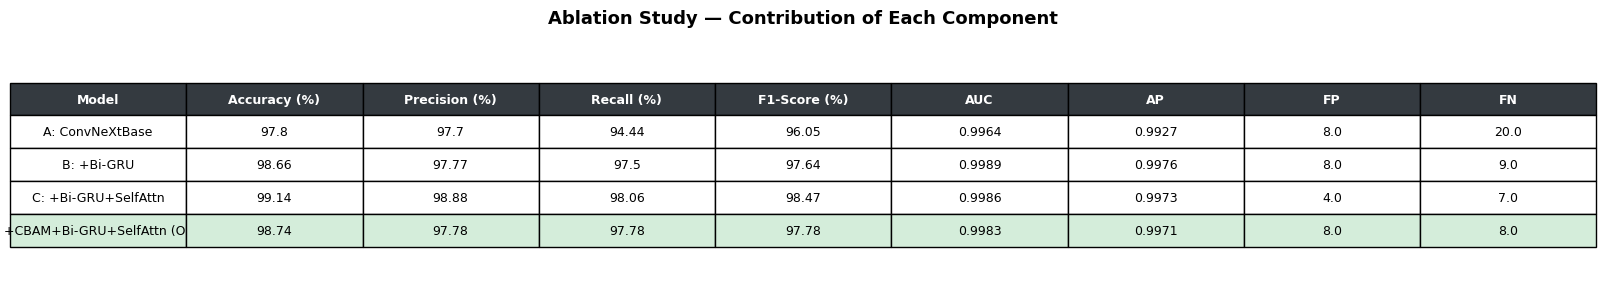

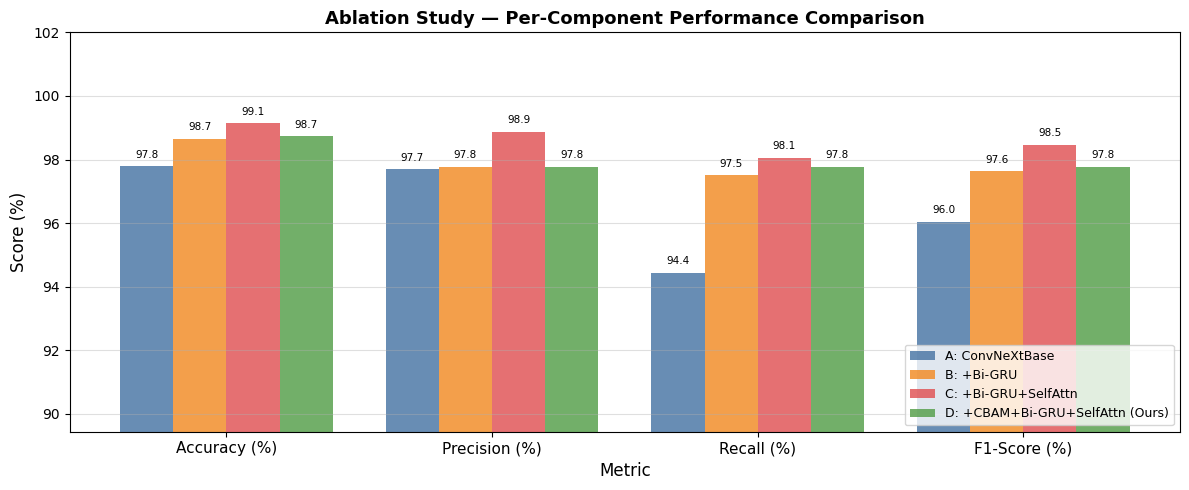

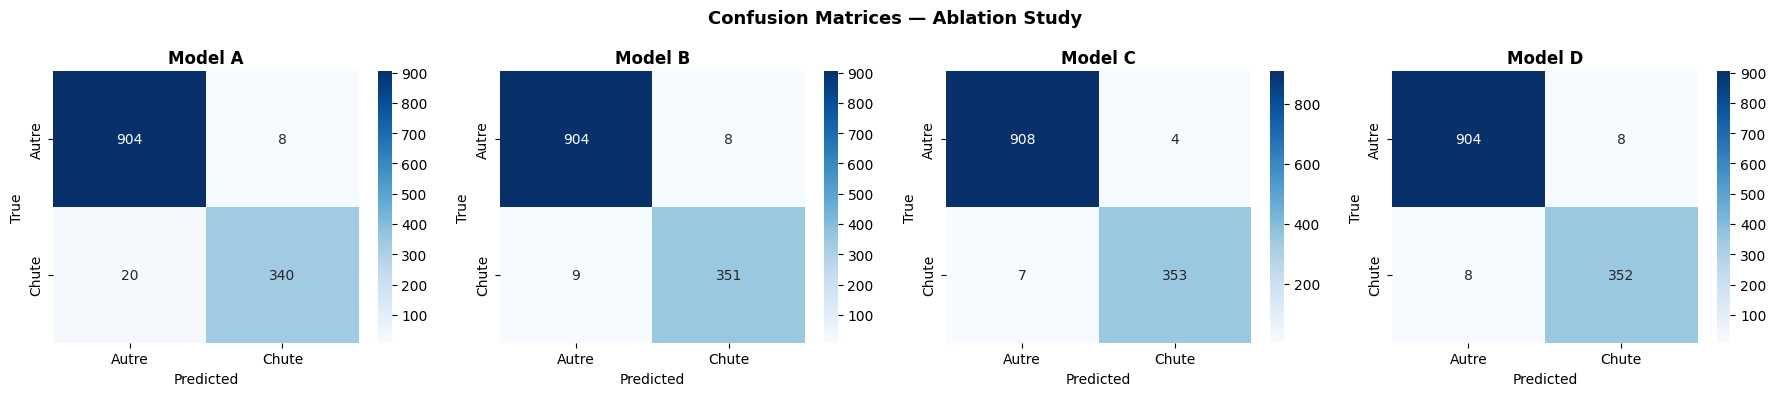


[INFO] Ablation study terminée. Fichiers sauvegardés dans /kaggle/working/


In [3]:
# ablabation a executer apres la premier fenetre qui importe 

# ------------------------------------------------------------------------------
# CODE 2 : ABLATION STUDY — Modèles A, B, C, D
# Répond à : Reviewer #1 (point 1) — validation de la contribution de chaque composant
# ------------------------------------------------------------------------------
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# ── Définition des 4 architectures ──────────────────────────────────────────

def build_model_A(input_shape=(224, 224, 3)):
    """Modèle A : ConvNeXtBase seul (baseline)"""
    backbone = ConvNeXtBase(include_top=False, weights='imagenet',
                             input_shape=input_shape, pooling='avg')
    backbone.trainable = False
    inputs = layers.Input(shape=input_shape)
    x = backbone(inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name="A_ConvNeXtBase")

def build_model_B(input_shape=(224, 224, 3)):
    """Modèle B : ConvNeXtBase + Bi-GRU"""
    backbone = ConvNeXtBase(include_top=False, weights='imagenet',
                             input_shape=input_shape, pooling=None)
    backbone.trainable = False
    inputs = layers.Input(shape=input_shape)
    x = backbone(inputs)
    x = layers.Lambda(lambda t: tf.reshape(t, (tf.shape(t)[0], -1, tf.shape(t)[-1])))(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=False))(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name="B_ConvNeXt_BiGRU")

def build_model_C(input_shape=(224, 224, 3)):
    """Modèle C : ConvNeXtBase + Bi-GRU + Self-Attention"""
    backbone = ConvNeXtBase(include_top=False, weights='imagenet',
                             input_shape=input_shape, pooling=None)
    backbone.trainable = False
    inputs = layers.Input(shape=input_shape)
    x = backbone(inputs)
    x = layers.Lambda(lambda t: tf.reshape(t, (tf.shape(t)[0], -1, tf.shape(t)[-1])))(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Attention()([x, x])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name="C_ConvNeXt_BiGRU_SelfAttn")

def build_model_D(input_shape=(224, 224, 3)):
    """Modèle D (le vôtre) : ConvNeXtBase + CBAM + Bi-GRU + Self-Attention"""
    backbone = ConvNeXtBase(include_top=False, weights='imagenet',
                             input_shape=input_shape, pooling=None)
    backbone.trainable = False

    def spatial_attention(x):
        avg_pool = layers.Lambda(lambda t: tf.reduce_mean(t, axis=3, keepdims=True))(x)
        max_pool = layers.Lambda(lambda t: tf.reduce_max(t, axis=3, keepdims=True))(x)
        concat = layers.Concatenate(axis=3)([avg_pool, max_pool])
        cbam = layers.Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)
        return layers.Multiply()([x, cbam])

    inputs = layers.Input(shape=input_shape)
    x = backbone(inputs)
    x = spatial_attention(x)
    x = layers.Lambda(lambda t: tf.reshape(t, (tf.shape(t)[0], -1, tf.shape(t)[-1])))(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Attention()([x, x])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name="D_ConvNeXt_CBAM_BiGRU_SelfAttn")

# ── Entraînement et évaluation de chaque modèle ─────────────────────────────

model_builders = {
    'A: ConvNeXtBase': build_model_A,
    'B: +Bi-GRU': build_model_B,
    'C: +Bi-GRU+SelfAttn': build_model_C,
    'D: +CBAM+Bi-GRU+SelfAttn (Ours)': build_model_D,
}

ablation_results = {}
trained_models  = {}

callbacks_ablation = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2, monitor='val_loss')
]

steps_per_epoch  = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(test_generator.samples  / BATCH_SIZE)

for name, builder in model_builders.items():
    print(f"\n{'='*60}")
    print(f"[INFO] Entraînement du modèle : {name}")
    print('='*60)

    # Reset du générateur de test
    test_generator.reset()

    m = builder(IMG_SIZE + (3,))
    m.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall'),
                 'accuracy']
    )

    hist = m.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        validation_data=test_generator,
        validation_steps=validation_steps,
        epochs=EPOCHS,
        callbacks=callbacks_ablation,
        verbose=1
    )

    # ── Évaluation ──
    test_generator.reset()
    preds      = m.predict(test_generator, steps=validation_steps)
    pred_cls   = (preds > 0.5).astype(int).flatten()
    true_cls   = test_generator.classes[:len(pred_cls)]

    report = classification_report(true_cls, pred_cls,
                                   target_names=['autre', 'chute'],
                                   output_dict=True)
    cm     = confusion_matrix(true_cls, pred_cls)
    auc    = roc_auc_score(true_cls, preds[:len(true_cls)])
    ap     = average_precision_score(true_cls, preds[:len(true_cls)])

    tn, fp, fn, tp = cm.ravel()

    ablation_results[name] = {
        'Accuracy (%)':    round(report['accuracy'] * 100, 2),
        'Precision (%)':   round(report['chute']['precision'] * 100, 2),
        'Recall (%)':      round(report['chute']['recall'] * 100, 2),
        'F1-Score (%)':    round(report['chute']['f1-score'] * 100, 2),
        'AUC':             round(auc, 4),
        'AP':              round(ap, 4),
        'TP': int(tp), 'TN': int(tn),
        'FP': int(fp), 'FN': int(fn),
    }
    trained_models[name] = {'model': m, 'history': hist, 'preds': preds, 'true': true_cls}

    print(f"\n[RÉSULTAT] {name}")
    for k, v in ablation_results[name].items():
        print(f"  {k}: {v}")

# ── Tableau comparatif ───────────────────────────────────────────────────────

df_ablation = pd.DataFrame(ablation_results).T
print("\n" + "="*70)
print("TABLEAU D'ABLATION COMPLET")
print("="*70)
print(df_ablation.to_string())

# ── Figure : Tableau stylisé ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')

display_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'AUC', 'AP', 'FP', 'FN']
df_display   = df_ablation[display_cols].reset_index()
df_display.columns = ['Model'] + display_cols

table = ax.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.0)

# Mise en évidence de la ligne du modèle D
for j in range(len(df_display.columns)):
    table[(4, j)].set_facecolor('#d4edda')  # vert clair pour modèle D
    table[(0, j)].set_facecolor('#343a40')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

plt.title('Ablation Study — Contribution of Each Component', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_table.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure : Barres comparatives ─────────────────────────────────────────────

metrics_to_plot = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x   = np.arange(len(metrics_to_plot))
width = 0.2
colors = ['#4e79a7', '#f28e2b', '#e15759', '#59a14f']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(df_ablation.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=colors[i], alpha=0.85)
    # Affichage valeur sur barre
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Ablation Study — Per-Component Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim([max(0, df_ablation[metrics_to_plot].values.min() - 5), 102])
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure : Matrices de confusion côte-à-côte ───────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, data) in zip(axes, trained_models.items()):
    cm = confusion_matrix(data['true'], (data['preds'] > 0.5).astype(int).flatten())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Autre', 'Chute'],
                yticklabels=['Autre', 'Chute'])
    short = name.split(':')[0]
    ax.set_title(f'Model {short}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Ablation Study', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[INFO] Ablation study terminée. Fichiers sauvegardés dans /kaggle/working/")

In [8]:
import pandas as pd

# 1. Convertir le dictionnaire de scores existant en DataFrame
# (Chaque ligne = un run, chaque colonne = un modèle)
df_raw_scores = pd.DataFrame(all_scores)

# 2. Sauvegarder dans le répertoire de travail de Kaggle
csv_path = '/kaggle/working/all_runs_raw_scores.csv'
df_raw_scores.to_csv(csv_path, index=False)

print(f"[OK] Tous les scores bruts ont été sauvegardés avec succès dans : {csv_path}")
print(df_raw_scores)

[OK] Tous les scores bruts ont été sauvegardés avec succès dans : /kaggle/working/all_runs_raw_scores.csv
   A: ConvNeXtBase  B: +Bi-GRU  C: +Bi-GRU+SelfAttn  D: +CBAM+Bi-GRU+SelfAttn
0         0.926829    0.963415             0.967480                  0.951219
1         0.943089    0.971545             0.963415                  0.955285
2         0.943089    0.971545             0.967480                  0.971545
3         0.947154    0.967480             0.955285                  0.955285
4         0.930894    0.963415             0.967480                  0.963415
5         0.939024    0.975610             0.967480                  0.955285
6         0.943089    0.963415             0.967480                  0.971545


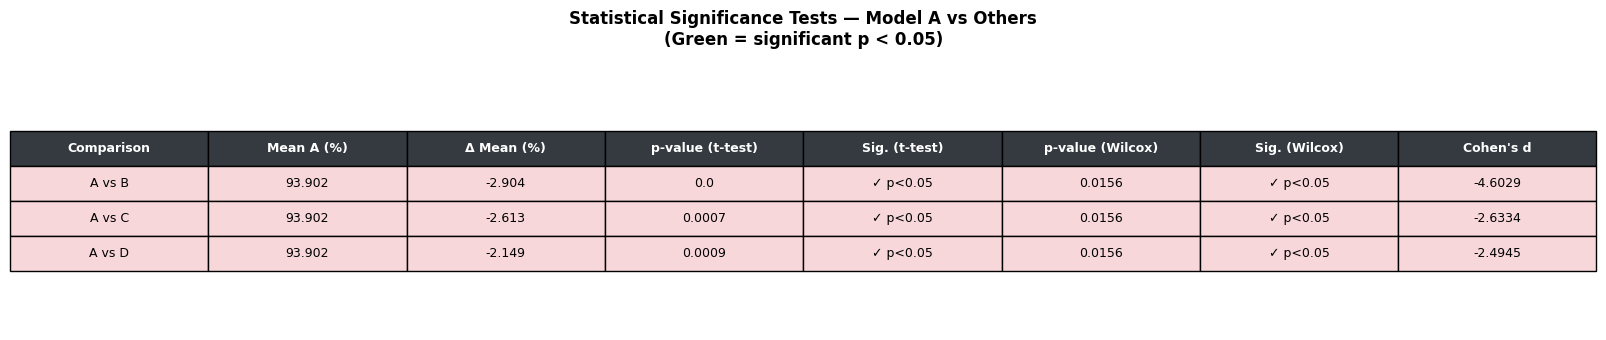

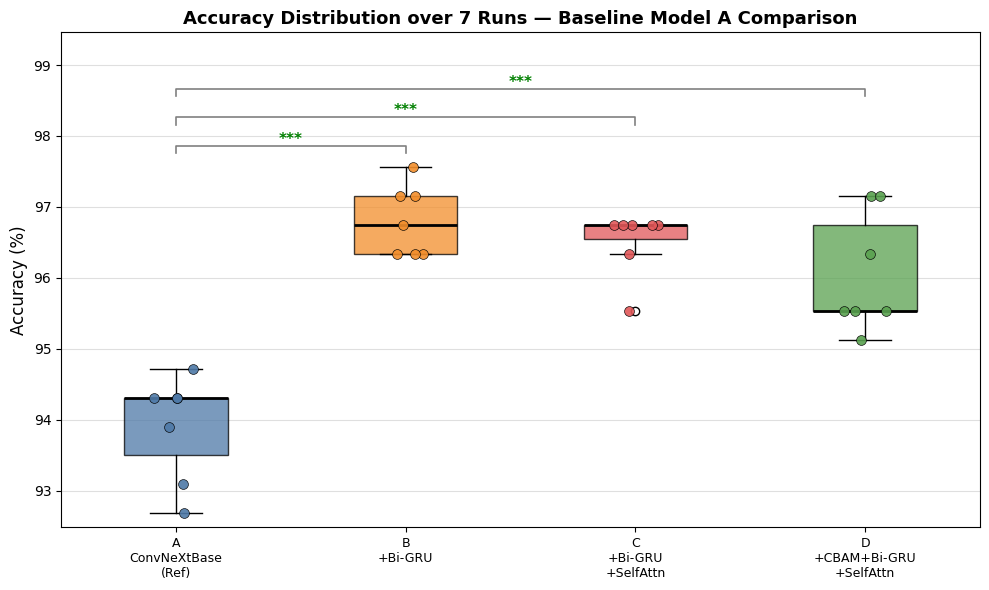

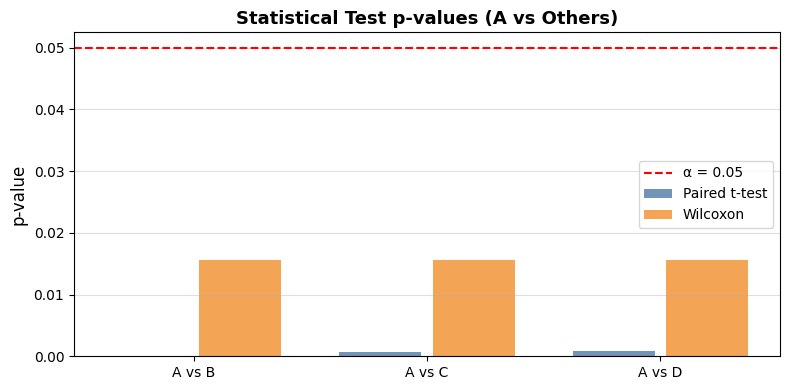


[INFO] Figures générées et rapports mis à jour. Comparaison centrée sur le modèle A.


In [10]:
# ==============================================================================
# CODE COMPLEMENTAIRE : FIGURES & TESTS STATISTIQUES CENTRÉS SUR LE MODÈLE A
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Figure 1 : Tableau des tests statistiques (A vs B, C, D) ──────────────────

# Recalculer les tests en prenant le Modèle A comme référence
scores_A = np.array(all_scores['A: ConvNeXtBase'])
comparisons_vs_A = ['B: +Bi-GRU', 'C: +Bi-GRU+SelfAttn', 'D: +CBAM+Bi-GRU+SelfAttn']

test_results = []
for comp_name in comparisons_vs_A:
    scores_X = np.array(all_scores[comp_name])

    t_stat, p_ttest = stats.ttest_rel(scores_A, scores_X)

    try:
        w_stat, p_wilcox = stats.wilcoxon(scores_A, scores_X)
    except ValueError:
        w_stat, p_wilcox = 0.0, 1.0

    diff = scores_A - scores_X
    cohens_d = diff.mean() / (diff.std() + 1e-9)

    sig_ttest  = "✓ p<0.05" if p_ttest  < 0.05 else "✗ ns"
    sig_wilcox = "✓ p<0.05" if p_wilcox < 0.05 else "✗ ns"

    test_results.append({
        'Comparison':       f'A vs {comp_name.split(":")[0]}',
        'Mean A (%)':       round(scores_A.mean()*100, 3),
        f'Mean {comp_name.split(":")[0]} (%)': round(scores_X.mean()*100, 3),
        'Δ Mean (%)':       round((scores_A.mean()-scores_X.mean())*100, 3),
        't-stat':           round(t_stat, 4),
        'p-value (t-test)': round(p_ttest, 4),
        'Sig. (t-test)':    sig_ttest,
        'W-stat':           round(w_stat, 4),
        'p-value (Wilcox)': round(p_wilcox, 4),
        'Sig. (Wilcox)':    sig_wilcox,
        "Cohen's d":        round(cohens_d, 4),
    })

df_tests = pd.DataFrame(test_results)

display_cols_test = ['Comparison', 'Mean A (%)', 'Δ Mean (%)',
                     'p-value (t-test)', 'Sig. (t-test)',
                     'p-value (Wilcox)', 'Sig. (Wilcox)', "Cohen's d"]

available_cols = [c for c in display_cols_test if c in df_tests.columns]
df_display_test = df_tests[available_cols]

fig, ax = plt.subplots(figsize=(16, 3.5))
ax.axis('off')
table = ax.table(
    cellText=df_display_test.values,
    colLabels=df_display_test.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.2)

# Coloriage automatique du tableau basé sur la colonne 'Sig. (t-test)'
for i, row in enumerate(df_tests.itertuples(), start=1):
    color = '#d4edda' if '✓' in str(row._5) else '#f8d7da'  # Position de Sig. (t-test)
    for j in range(len(available_cols)):
        table[(i, j)].set_facecolor(color)

for j in range(len(available_cols)):
    table[(0, j)].set_facecolor('#343a40')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

plt.title('Statistical Significance Tests — Model A vs Others\n(Green = significant p < 0.05)',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/kaggle/working/statistical_tests_table_A.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2 : Boxplot des distributions d'accuracy (Annotations centrées sur A) ──

fig, ax = plt.subplots(figsize=(10, 6))
data_box   = [np.array(all_scores[n])*100 for n in models_to_test]
labels_box = ['A\nConvNeXtBase\n(Ref)', 'B\n+Bi-GRU', 'C\n+Bi-GRU\n+SelfAttn', 'D\n+CBAM+Bi-GRU\n+SelfAttn']
colors_box = ['#4e79a7', '#f28e2b', '#e15759', '#59a14f']

bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for i, (data_pts, color) in enumerate(zip(data_box, colors_box), start=1):
    jitter = np.random.uniform(-0.1, 0.1, size=len(data_pts))
    ax.scatter(np.full(len(data_pts), i) + jitter, data_pts,
               color=color, zorder=5, s=50, alpha=0.9, edgecolors='black', linewidths=0.5)

# Zone d'annotation par rapport à la boîte A (position X = 1)
y_annot = max(d.max() for d in data_box) + 0.3
ref_pos = 1  
other_positions = [2, 3, 4]  # Positions de B, C, D sur l'axe X

for idx, row in df_tests.iterrows():
    p = row['p-value (t-test)']
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    
    x1 = ref_pos
    x2 = other_positions[idx]
    x_left, x_right = min(x1, x2), max(x1, x2)
    
    # Hauteurs incrémentales pour éviter que les barres ne se chevauchent
    h = y_annot + idx * 0.4
    
    ax.plot([x_left, x_left, x_right, x_right], [h-0.1, h, h, h-0.1], lw=1.2, color='gray')
    ax.text((x_left+x_right)/2, h + 0.03, sig, ha='center', fontsize=11, fontweight='bold',
            color='green' if sig != 'ns' else 'red')

ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels_box, fontsize=9)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(f'Accuracy Distribution over {N_RUNS} Runs — Baseline Model A Comparison',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.4)

# Ajustement des limites de l'axe Y pour intégrer proprement les barres
ax.set_ylim(bottom=min(d.min() for d in data_box) - 0.2, top=y_annot + len(df_tests)*0.4 + 0.4)

plt.tight_layout()
plt.savefig('/kaggle/working/statistical_boxplot_A.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3 : p-values visualisées (A vs Others) ─────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))
comp_labels  = [r['Comparison'] for r in test_results]
p_ttest_vals = [r['p-value (t-test)'] for r in test_results]
p_wilcox_vals = [r['p-value (Wilcox)'] for r in test_results]

x_pos = np.arange(len(comp_labels))
ax.bar(x_pos - 0.2, p_ttest_vals,  0.35, label="Paired t-test", color='#4e79a7', alpha=0.8)
ax.bar(x_pos + 0.2, p_wilcox_vals, 0.35, label="Wilcoxon",        color='#f28e2b', alpha=0.8)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
ax.set_xticks(x_pos)
ax.set_xticklabels(comp_labels, fontsize=10)
ax.set_ylabel('p-value', fontsize=12)
ax.set_title('Statistical Test p-values (A vs Others)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/pvalue_chart_A.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarde des résultats au format CSV
df_tests.to_csv('/kaggle/working/statistical_tests_results_A.csv', index=False)
print("\n[INFO] Figures générées et rapports mis à jour. Comparaison centrée sur le modèle A.")